ARTI308 - Machine Learning

# Lab 3: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

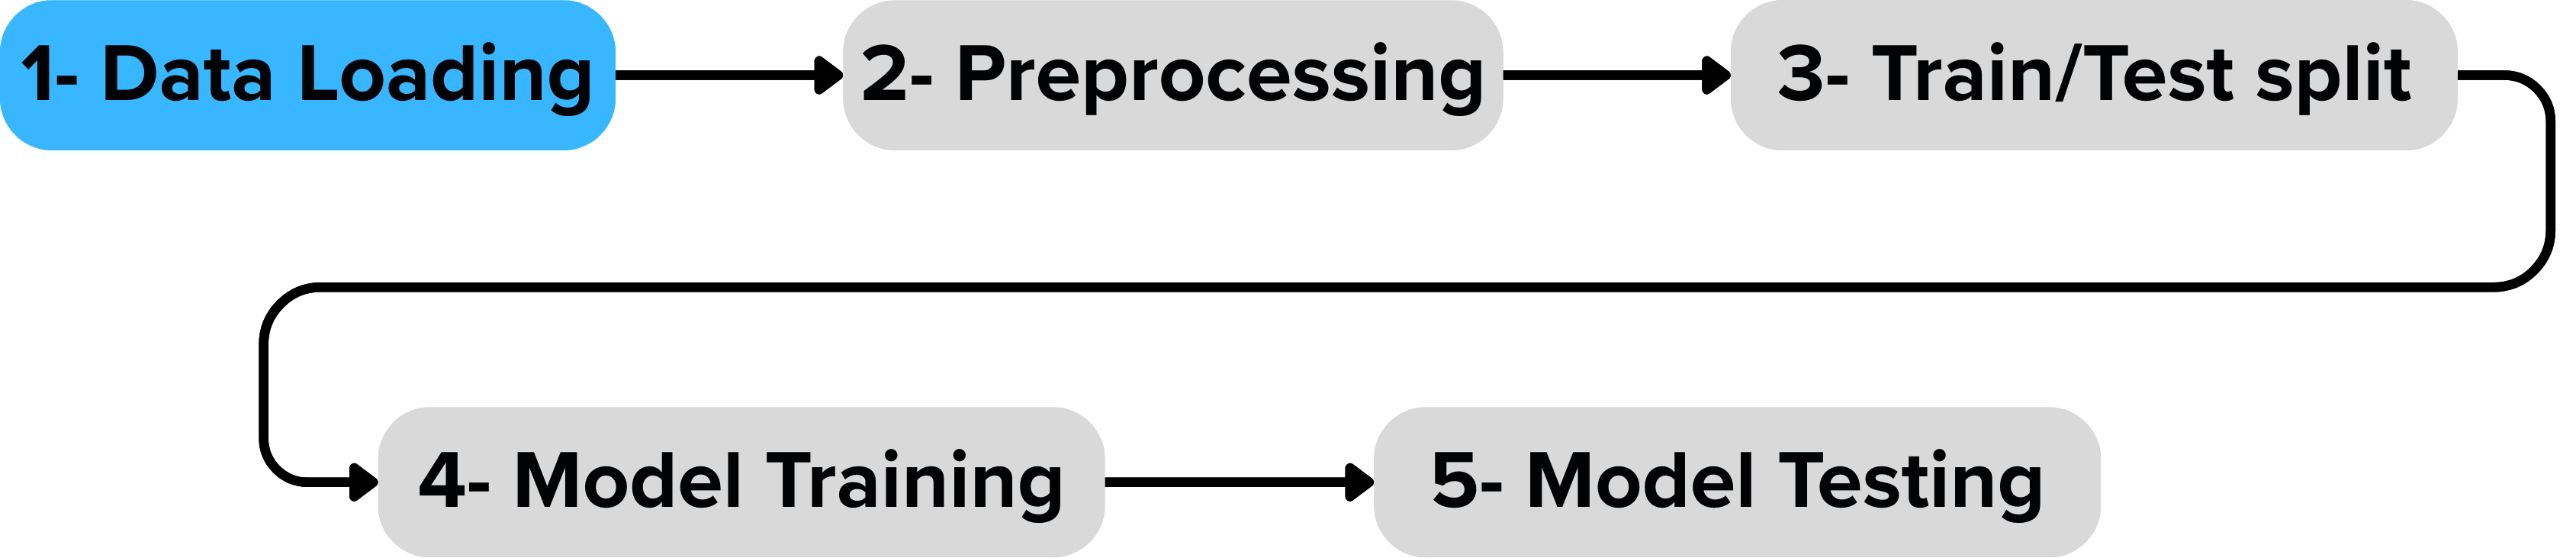

In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [3]:
# Load Dataset

df = pd.read_csv("global_cars_enhanced.csv")

# Display first 5 rows
df.head()

,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country,Car_Age,Price_Category,HP_per_CC,Age_Category,Efficiency_Score
0,CAR_0001,Mercedes,2006,SUV,Petrol,Manual,4089,547,17,73407,USA,20,Premium,0.1338,Old,0.35
1,CAR_0002,Nissan,2023,Coupe,Petrol,Automatic,4618,167,25,79370,USA,3,Premium,0.0362,New,0.75
2,CAR_0003,Nissan,2007,Hatchback,Diesel,Manual,1802,110,16,76549,China,19,Premium,0.0610,Old,0.30
3,CAR_0004,Nissan,2013,Coupe,Petrol,Manual,1835,373,16,48722,USA,13,Mid-Range,0.2033,Old,0.30
4,CAR_0005,Hyundai,2009,Hatchback,Hybrid,Automatic,2332,145,28,83265,UK,17,Premium,0.0622,Old,0.90


### Check Missing Values

In [4]:
# Check all values
print(df.isna())

     Car_ID  Brand  Manufacture_Year  Body_Type  Fuel_Type  Transmission  \
0     False  False             False      False      False         False   
1     False  False             False      False      False         False   
2     False  False             False      False      False         False   
3     False  False             False      False      False         False   
4     False  False             False      False      False         False   
..      ...    ...               ...        ...        ...           ...   
295   False  False             False      False      False         False   
296   False  False             False      False      False         False   
297   False  False             False      False      False         False   
298   False  False             False      False      False         False   
299   False  False             False      False      False         False   

     Engine_CC  Horsepower  Mileage_km_per_l  Price_USD  \
0        False       False  

In [ ]:
#Checks for missing (null) values in each column and shows how many are there in total
print(df.isna().sum())

Car_ID                   0
Brand                    0
Manufacture_Year         0
Body_Type                0
Fuel_Type                0
Transmission             0
Engine_CC                0
Horsepower               0
Mileage_km_per_l         0
Price_USD                0
Manufacturing_Country    0
Car_Age                  0
Price_Category           0
HP_per_CC                0
Age_Category             0
Efficiency_Score         0
dtype: int64


### Check duplicate rows

In [6]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

### No. of rows and columns

In [7]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (300, 16) 

number of rows:  300
number of columns:  16


### Data type of columns

In [8]:
# viewing the data types of columns
df.dtypes

Car_ID                       str
Brand                        str
Manufacture_Year           int64
Body_Type                    str
Fuel_Type                    str
Transmission                 str
Engine_CC                  int64
Horsepower                 int64
Mileage_km_per_l           int64
Price_USD                  int64
Manufacturing_Country        str
Car_Age                    int64
Price_Category               str
HP_per_CC                float64
Age_Category                 str
Efficiency_Score         float64
dtype: object

In [ ]:
#Converts year and price columns into correct data types, calculates the car’s age, and displays the updated data types

df['Manufacture_Year'] = pd.to_datetime(df['Manufacture_Year'], format='%Y')
df['Price_USD'] = pd.to_numeric(df['Price_USD'])
df['Car_Age_Calculated'] = 2026 - df['Manufacture_Year'].dt.year

df.dtypes

Car_ID                              str
Brand                               str
Manufacture_Year         datetime64[us]
Body_Type                           str
Fuel_Type                           str
Transmission                        str
Engine_CC                         int64
Horsepower                        int64
Mileage_km_per_l                  int64
Price_USD                         int64
Manufacturing_Country               str
Car_Age                           int64
Price_Category                      str
HP_per_CC                       float64
Age_Category                        str
Efficiency_Score                float64
Car_Age_Calculated                int32
dtype: object

### Descriptive summary Statistics

In [10]:
# Statistical summary
df.describe(include='all')

,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country,Car_Age,Price_Category,HP_per_CC,Age_Category,Efficiency_Score,Car_Age_Calculated
count,300,300,300,300,300,300,300.000000,300.000000,300.000000,300.000000,300,300.000000,300,300.000000,300,300.000000,300.000000
unique,300,10,NaN,5,4,2,NaN,NaN,NaN,NaN,6,NaN,4,NaN,4,NaN,NaN
top,CAR_0001,Nissan,NaN,Sedan,Petrol,Manual,NaN,NaN,NaN,NaN,Germany,NaN,Budget,NaN,Old,NaN,NaN
freq,1,41,NaN,70,77,155,NaN,NaN,NaN,NaN,55,NaN,78,NaN,126,NaN,NaN
mean,NaN,NaN,2015-02-15 04:28:48,NaN,NaN,NaN,3052.880000,328.346667,19.716667,60848.823333,NaN,10.876667,NaN,0.129559,NaN,0.485833,10.876667
min,NaN,NaN,2005-01-01 00:00:00,NaN,NaN,NaN,1001.000000,70.000000,10.000000,5221.000000,NaN,1.000000,NaN,0.017800,NaN,0.000000,1.000000
25%,NaN,NaN,2010-01-01 00:00:00,NaN,NaN,NaN,2074.000000,188.250000,15.000000,29418.500000,NaN,6.000000,NaN,0.063250,NaN,0.250000,6.000000
50%,NaN,NaN,2015-01-01 00:00:00,NaN,NaN,NaN,3117.500000,329.500000,19.500000,59179.500000,NaN,11.000000,NaN,0.106850,NaN,0.475000,11.000000
75%,NaN,NaN,2020-01-01 00:00:00,NaN,NaN,NaN,3964.000000,454.750000,24.000000,89692.250000,NaN,16.000000,NaN,0.168325,NaN,0.700000,16.000000
max,NaN,NaN,2025-01-01 00:00:00,NaN,NaN,NaN,4994.000000,599.000000,30.000000,119587.000000,NaN,21.000000,NaN,0.525500,NaN,1.000000,21.000000


### Distribution of Manufacturing Countries

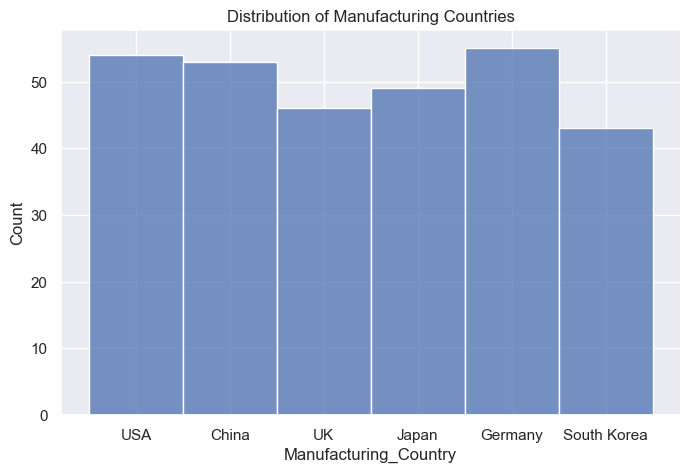

In [ ]:
#Visualizes the frequency distribution of cars based on their manufacturing country

plt.figure(figsize=(8,5))
sns.histplot(df['Manufacturing_Country'], bins=20)
plt.title("Distribution of Manufacturing Countries")
plt.show()

- Shows how shipment sizes are distributed
- Right skew = many small shipments, few large ones

### Fuel Type Distribution

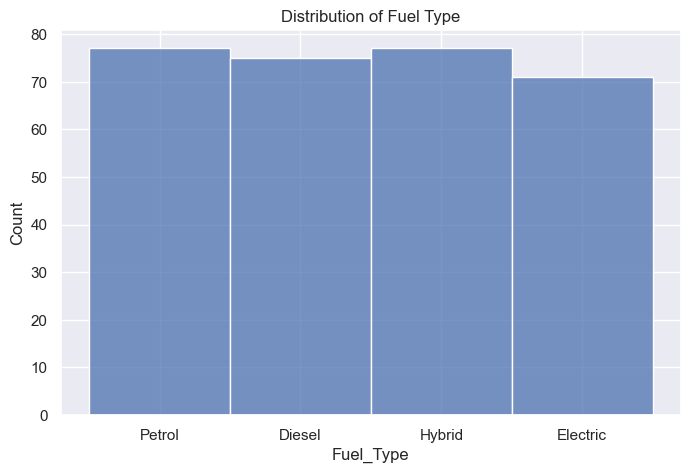

In [ ]:
#Shows how different fuel types are distributed in the dataset
plt.figure(figsize=(8,5))
sns.histplot(df['Fuel_Type'], bins=20)
plt.title("Distribution of Fuel Type")
plt.show()

## Bivariate Analysis

### Horse Power per Cubic Centimeter

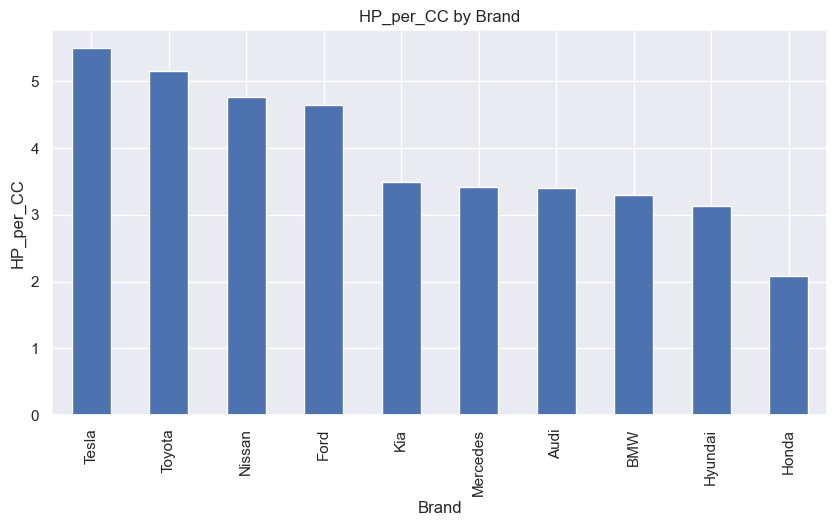

Brand
Tesla       5.4894
Toyota      5.1582
Nissan      4.7607
Ford        4.6419
Kia         3.4958
Mercedes    3.4088
Audi        3.3972
BMW         3.2920
Hyundai     3.1352
Honda       2.0886
Name: HP_per_CC, dtype: float64

In [ ]:
#Groups data by car brand, sums performance efficiency, and displays a bar chart of brand performance

HPperCC = df.groupby('Brand')['HP_per_CC'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
HPperCC.plot(kind='bar')
plt.title("HP_per_CC by Brand")
plt.ylabel("HP_per_CC")
plt.show()

HPperCC

### Price by Brand

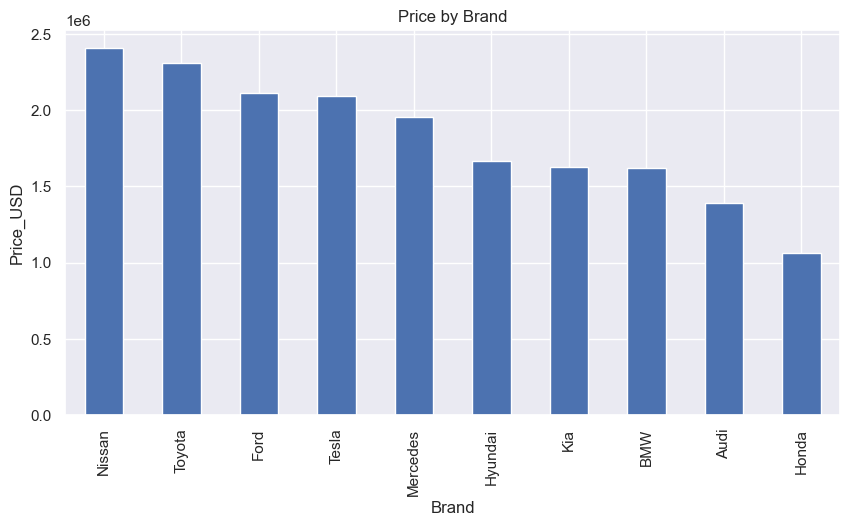

Brand
Nissan      2404845
Toyota      2311397
Ford        2113879
Tesla       2091404
Mercedes    1955715
Hyundai     1668027
Kia         1628569
BMW         1622726
Audi        1393331
Honda       1064754
Name: Price_USD, dtype: int64

In [ ]:
#Calculates total price value for each brand and visualizes which brands generate the highest revenue
price = df.groupby('Brand')['Price_USD'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
price.plot(kind='bar')
plt.title("Price by Brand")
plt.ylabel("Price_USD")
plt.show()

price

### Horsepower by Brand

In [ ]:
#Shows the top 10 brands with the highest total horsepower
BrandHp = df.groupby('Brand')['Horsepower'].sum().sort_values(ascending=False)

BrandHp.head(10)

Brand
Tesla       13170
Nissan      12702
Ford        12656
Toyota      12475
Mercedes     9463
Kia          9184
Audi         8098
BMW          7690
Hyundai      7667
Honda        5399
Name: Horsepower, dtype: int64

### Brand vs Car_Age

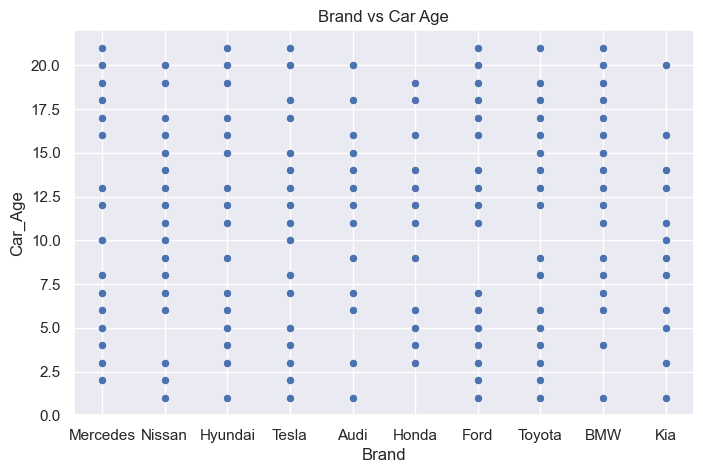

In [ ]:
#Displays the relationship between car brands and their ages
plt.figure(figsize=(8,5))
sns.scatterplot(x='Brand', y='Car_Age', data=df)
plt.title("Brand vs Car Age")
plt.show()

### Correlation Matrix

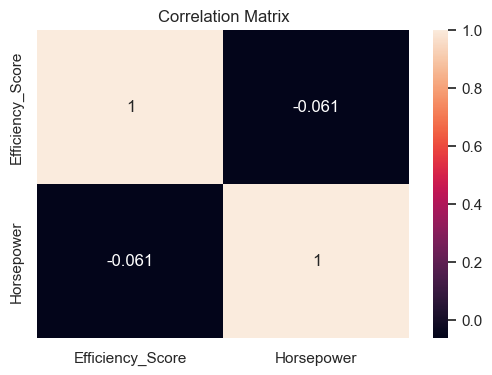

In [ ]:
#Shows correlation between efficiency score and horsepower to identify any relationship
plt.figure(figsize=(6,4))
sns.heatmap(df[['Efficiency_Score', 'Horsepower']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship

## Time-Based Analysis
### Price Trend

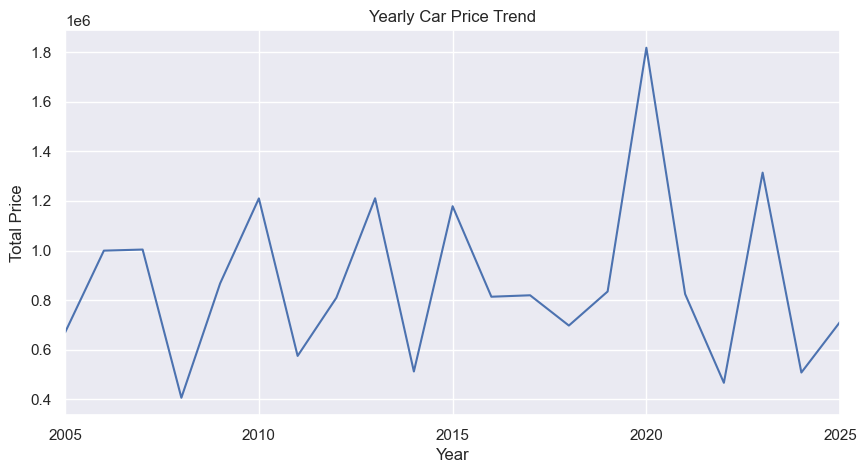

In [ ]:
#Converts year format, groups prices by year, and visualizes the yearly trend in car prices
df['Manufacture_Year'] = pd.to_datetime(df['Manufacture_Year'], format='%Y')

df['Year'] = df['Manufacture_Year'].dt.to_period('Y')

yearly_price = df.groupby('Year')['Price_USD'].sum()

plt.figure(figsize=(10,5))
yearly_price.plot()
plt.title("Yearly Car Price Trend")
plt.ylabel("Total Price")
plt.show()

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the dataset file with your notebook.


End of lab 3.